# ***DATA ANALYSIS PYTHON PROJECT - Blinkit Analysis***

### ***Importing Libraries***

In [1]:
# Importing Important Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### ***Importing Raw Data***

In [2]:
# Read the CSV file in pandas
df = pd.read_csv('blinkit_data.csv')

### ***Sample Data***

In [3]:
df

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2000,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,low fat,NCT53,Health and Hygiene,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,164.5526,4.0
8519,low fat,FDN09,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.034706,NaN,241.6828,4.0
8520,low fat,DRE13,Soft Drinks,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.027571,NaN,86.6198,4.0
8521,reg,FDT50,Dairy,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.107715,NaN,97.8752,4.0


### ***Size of Dataset***

In [4]:
print('Size of the dataset is{Row, Col} :', df.shape)

Size of the dataset is{Row, Col} : (8523, 12)


### ***Field Info***

In [5]:
df.columns

Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Sales', 'Rating'],
      dtype='object')

### ***Data Type***

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item Fat Content           8523 non-null   object 
 1   Item Identifier            8523 non-null   object 
 2   Item Type                  8523 non-null   object 
 3   Outlet Establishment Year  8523 non-null   int64  
 4   Outlet Identifier          8523 non-null   object 
 5   Outlet Location Type       8523 non-null   object 
 6   Outlet Size                8523 non-null   object 
 7   Outlet Type                8523 non-null   object 
 8   Item Visibility            8523 non-null   float64
 9   Item Weight                7060 non-null   float64
 10  Sales                      8523 non-null   float64
 11  Rating                     8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


### ***Data Cleaning***

In [7]:
print(df['Item Fat Content'].unique())

['Regular' 'Low Fat' 'low fat' 'LF' 'reg']


In [8]:
df['Item Fat Content'] = df['Item Fat Content'].replace({'low fat':'Low Fat','LF':'Low Fat','reg':'Regular'})

In [9]:
print(df['Item Fat Content'].unique())

['Regular' 'Low Fat']


In [10]:
df.head()

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2000,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0


## ***BUSINESS REQUIREMENT***

### ***KPIs(Key Performance Indicator) REQUIREMENTS***

In [11]:
# Total Sales
total_sales = df['Sales'].sum()

#Average sales
Avg_sales = df['Sales'].mean()

# No. of Items
N_of_items = df['Item Identifier'].count()

# Average Ratings
Avg_rating = df['Rating'].mean()

print(f'Total Sales : ${total_sales:,.1f}')
print(f'Average Sales : ${Avg_sales:,.1f}')
print(f'No. of items : {N_of_items:,.1f}')
print(f'Average ratings : {Avg_rating:,.1f}')


Total Sales : $1,201,681.5
Average Sales : $141.0
No. of items : 8,523.0
Average ratings : 4.0


### ***Chart REQUIREMENTS***

#### ***Total Sales by Fat content***

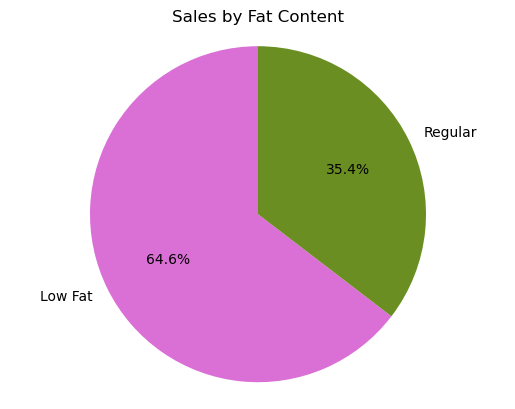

In [73]:
sales_fat = df.groupby('Item Fat Content')['Sales'].sum()
c = ['orchid','olivedrab']
plt.pie(sales_fat, labels = sales_fat.index, autopct = '%.1f%%',startangle = 90, colors = c)
plt.title('Sales by Fat Content')
plt.axis('equal')
plt.show()

#### ***Total Sales by Item Type***

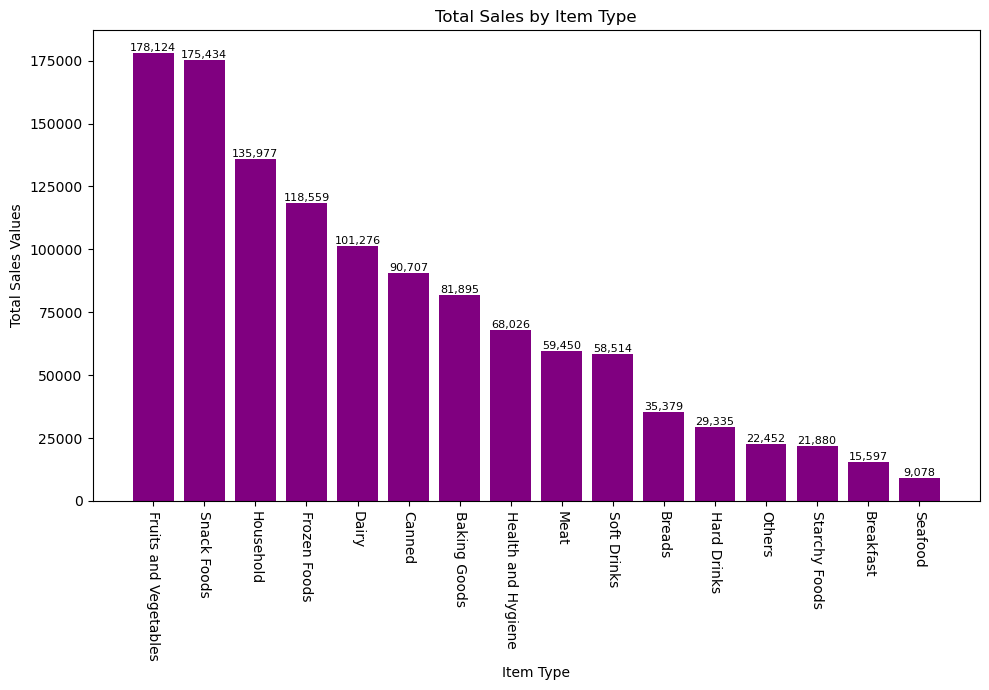

In [64]:
plt.figure(figsize = (10,7))
item_sales = df.groupby('Item Type')['Sales'].sum().sort_values(ascending = False)
bars = plt.bar(item_sales.index, item_sales.values, color = 'purple')
plt.xticks(rotation = -90)
plt.title('Total Sales by Item Type')
plt.xlabel('Item Type')
plt.ylabel('Total Sales Values')
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height(), f'{bar.get_height():,.0f}', va = 'bottom', ha = 'center', fontsize = 8)

plt.tight_layout()
plt.show()

#### ***Fat content by outlet for Total Sales***

<Figure size 1200x500 with 0 Axes>

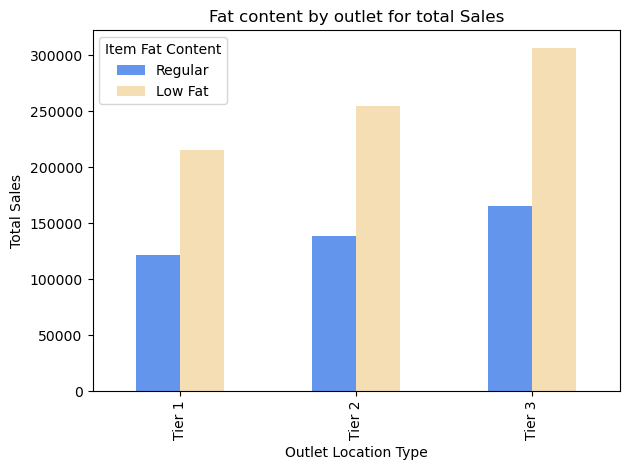

In [70]:
plt.figure(figsize = (12,5))
grouped = df.groupby(['Outlet Location Type','Item Fat Content'])['Sales'].sum().unstack()
grouped = grouped[['Regular','Low Fat']]
ex = grouped.plot(kind = 'bar', color = ['cornflowerblue','wheat'])
plt.title('Fat content by outlet for total Sales')
plt.xlabel('Outlet Location Type')
plt.ylabel('Total Sales')
plt.legend(title = 'Item Fat Content')
plt.tight_layout()
plt.show()


#### ***Total Sales by Outlet Establishment***

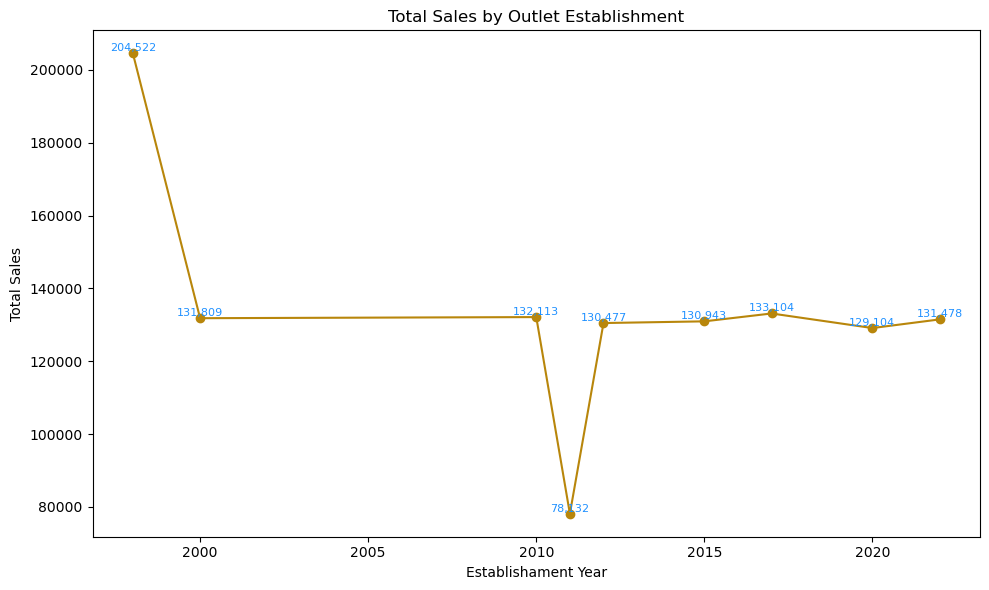

In [79]:
plt.figure(figsize = (10,6))
sales_est = df.groupby('Outlet Establishment Year')['Sales'].sum().sort_index()
plt.plot(sales_est.index, sales_est.values, marker = 'o', color = 'darkgoldenrod')
plt.title('Total Sales by Outlet Establishment')
plt.xlabel('Establishament Year')
plt.ylabel('Total Sales')
for x,y in zip(sales_est.index, sales_est.values):
    plt.text(x,y, f'{y:,.0f}', ha = 'center', va = 'bottom', fontsize = 8, color = 'dodgerblue')

plt.tight_layout()
plt.show()

#### ***Sales by Outlet size***

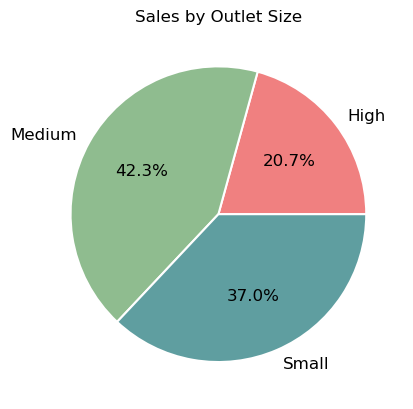

In [69]:
outlet_sales = df.groupby('Outlet Size')['Sales'].sum()
c = ['lightcoral','darkseagreen','cadetblue']
plt.pie(outlet_sales, labels = outlet_sales.index, autopct = '%.1f%%', wedgeprops = {'linewidth':1.5, 'edgecolor':'white'}, textprops = {'size':12}, colors = c)
plt.title('Sales by Outlet Size')
plt.show()

#### ***Sales by Outlet Location***

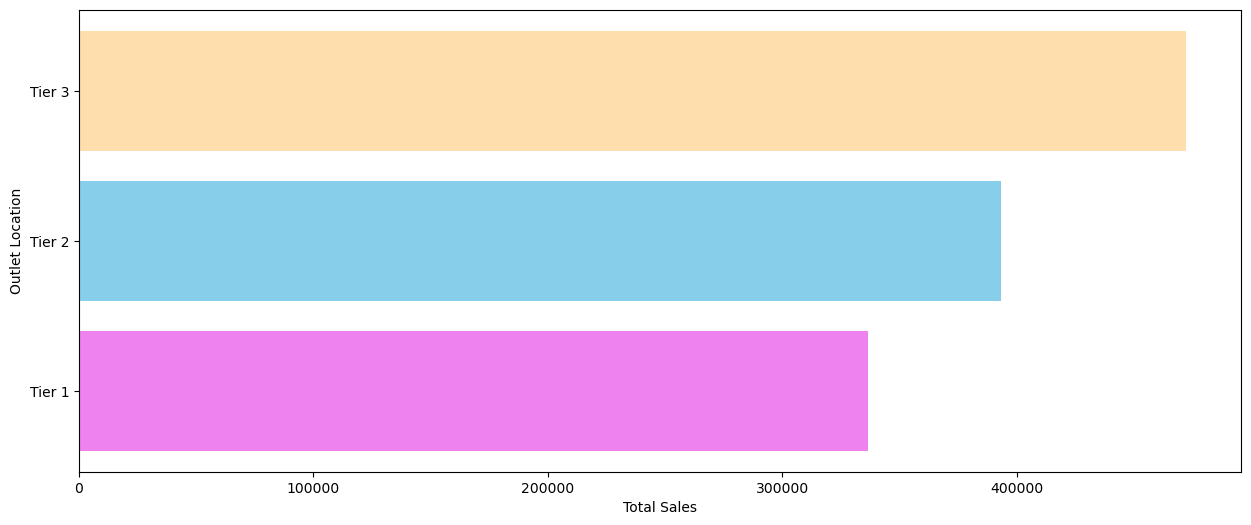

In [67]:
plt.figure(figsize = (15,6))
outlet_loc = df.groupby('Outlet Location Type')['Sales'].sum()
c = ['violet','skyblue','navajowhite']
plt.barh(outlet_loc.index, outlet_loc.values, color = c)
plt.xlabel('Total Sales')
plt.ylabel('Outlet Location')
plt.show()